In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

Carga de las librerías necesarias y del dataset original en crudo: la versión completa de `listings`, con 90 columnas.

**Nota de alcance**: Inside Airbnb no publica un export separado para Palma de Mallorca. El único disponible para la isla es el de **Mallorca completa** (14.817 anuncios, 53 municipios). Se decide trabajar con la isla entera en vez de filtrar solo Palma: Palma son 949 anuncios (6,4% del total) que comparten un único valor de `neighbourhood_cleansed`, sin ninguna subdivisión geográfica interna en este dataset: filtrar dejaría el análisis sin ninguna variable de zona. Con la isla completa, los 53 municipios funcionan como geografía plana, igual que los 11 distritos de Málaga, pero con mucha más variación (costa turística, interior agrícola, pueblos de montaña).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(f"{PROJECT_DIR}/data/raw/mallorca/listings.csv.gz")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1594759156338136230,https://www.airbnb.com/rooms/1594759156338136230,20260623040707,2026-06-23,city scrape,S'Hortet Gran,Arrive and feel at home.,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,141515273,...,NaN,NaN,NaN,Mallorca - Regional registration number<br />E...,NaN,48,48,0,0,NaN
1,1273823517224415510,https://www.airbnb.com/rooms/1273823517224415510,20260623040707,2026-06-23,city scrape,Son Pere Genet,ETV 411 Recharge your batteries in this wonder...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,651077862,...,5.00,4.86,4.86,Spain - National registration number<br />ESFC...,NaN,1,1,0,0,0.47
2,1151380048474115597,https://www.airbnb.com/rooms/1151380048474115597,20260623040707,2026-06-23,city scrape,Ca Na Reieta by Vintage Travel,Ground Floor: Open plan living/dining room (TV...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,565714005,...,NaN,NaN,NaN,Mallorca - Regional registration number<br />E...,NaN,40,40,0,0,NaN
3,1430444173039950930,https://www.airbnb.com/rooms/1430444173039950930,20260623040707,2026-06-23,city scrape,Villa Sofía,Vacation villa for 8 people with fenced pool a...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,29095214,...,NaN,NaN,NaN,Spain - National registration number<br />ESFC...,NaN,24,24,0,0,NaN
4,1071698089211240769,https://www.airbnb.com/rooms/1071698089211240769,20260623040707,2026-06-23,city scrape,Villa Cuxach de N'Alba By SunVillas Mallorca,Villa Cuxach de n'Alba is a completely renovat...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,21160030,...,4.92,4.50,4.42,Spain - National registration number<br />ESFC...,NaN,57,57,0,0,0.46


## 2. Básico

Primer vistazo a la estructura del dataset: dimensiones, tipos de datos y estadísticos descriptivos generales.

In [3]:
print(df.shape)
df.dtypes.value_counts()

(14817, 90)


float64    37
object     29
int64      24
Name: count, dtype: int64

90 columnas (14.817 filas): mismo reparto de tipos que Barcelona/Madrid/Valencia/Málaga/Sevilla: señal de que las seis vienen del mismo export de Inside Airbnb. `price` es `object` en vez de numérico (se corrige en la sección 3), y hay columnas `float64` que por su nombre deberían ser texto o fecha (`host_since`, `host_response_time`...), lo que hace sospechar que están vacías.

In [4]:
null_pct = (df.isnull().mean() * 100).round(2)
null_pct[null_pct == 100].sort_index()

calendar_updated                100.0
host_acceptance_rate            100.0
host_neighbourhood              100.0
host_response_rate              100.0
host_response_time              100.0
host_since                      100.0
host_thumbnail_url              100.0
host_total_listings_count       100.0
host_verifications              100.0
instant_bookable                100.0
neighborhood_overview           100.0
neighbourhood                   100.0
neighbourhood_group_cleansed    100.0
dtype: float64

**13 columnas completamente vacías** (100% nulas): las mismas 12 comunes a todas las ciudades, más `neighbourhood_group_cleansed`, igual que en Málaga, sin jerarquía distrito/barrio por encima de `neighbourhood_cleansed`. De las 90 columnas, solo 77 tienen algún dato real. No se eliminan aquí, se tratan formalmente en la sección 4 (Nulos).

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,14817.0,6.558743e+17,6.725973e+17,6.999800e+04,3.075303e+07,6.176927e+17,1.345655e+18,1.713243e+18
scrape_id,14817.0,2.026062e+13,3.906382e-03,2.026062e+13,2.026062e+13,2.026062e+13,2.026062e+13,2.026062e+13
neighborhood_overview,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,14817.0,1.340283e+16,1.495978e+17,1.865100e+04,5.724898e+07,1.298223e+08,3.497213e+08,1.709281e+18
host_profile_id,14817.0,1.474317e+18,3.528204e+16,1.462507e+18,1.462983e+18,1.467264e+18,1.469325e+18,1.712946e+18
...,...,...,...,...,...,...,...,...
calculated_host_listings_count,14817.0,8.301215e+01,1.756967e+02,1.000000e+00,3.000000e+00,2.500000e+01,7.400000e+01,7.910000e+02
calculated_host_listings_count_entire_homes,14817.0,8.126686e+01,1.706541e+02,0.000000e+00,2.000000e+00,2.500000e+01,7.400000e+01,7.670000e+02
calculated_host_listings_count_private_rooms,14817.0,1.727003e+00,5.583626e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.400000e+01
calculated_host_listings_count_shared_rooms,14817.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


`price` llega como texto (`"$319.60"`, no `319.60`), con la misma familia `price_quote_*` de siempre. Ya destaca aquí algo propio de Mallorca: **25,4% de nulos en `price`** (frente al 5-10% habitual en las otras ciudades), se retoma en la sección 4.

## 3. Corrección de tipos

Ajustar columnas con un tipo de dato mal inferido. Mismos pasos que en las otras ciudades, aplicados aquí a Mallorca.

#### `price`

Llega como texto con símbolo de moneda y separador de miles. Se limpia y se convierte a `float`.

In [6]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
df["price"].dtype

dtype('float64')

#### Fechas

`last_scraped`, `first_review`, `last_review` y `calendar_last_scraped` son fechas guardadas como texto. `host_since` se deja fuera: es una de las 13 columnas 100% vacías (se eliminará en la sección 4).

In [7]:
date_cols = ["last_scraped", "first_review", "last_review", "calendar_last_scraped"]
df[date_cols] = df[date_cols].apply(pd.to_datetime)
df[date_cols].dtypes

last_scraped             datetime64[ns]
first_review             datetime64[ns]
last_review              datetime64[ns]
calendar_last_scraped    datetime64[ns]
dtype: object

#### Flags `t`/`f`

`host_is_superhost`, `host_has_profile_pic`, `host_identity_verified` y `has_availability` son booleanos codificados como texto (`"t"`/`"f"`), con algún nulo suelto. Se mapean a `boolean` (tipo nullable de pandas).

In [8]:
bool_cols = ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "has_availability"]
df[bool_cols] = df[bool_cols].apply(lambda s: s.map({"t": True, "f": False}).astype("boolean"))
df[bool_cols].dtypes

host_is_superhost         boolean
host_has_profile_pic      boolean
host_identity_verified    boolean
has_availability          boolean
dtype: object

#### `host_profile_id`

A diferencia de las demás ciudades (donde llegaba como `float64` con nulos y había que pasarlo a `Int64`), aquí llega ya como `int64` sin ningún nulo: no hace falta ninguna conversión.

In [9]:
df["host_profile_id"].dtype, df["host_profile_id"].isnull().sum()

(dtype('int64'), np.int64(0))

#### `neighbourhood_cleansed`: ¿normalizar mayúsculas?

Se prueba la misma función `title_case_place()` usada en Barcelona/Madrid para detectar mayúsculas sueltas.

In [10]:
import re

_SMALL_WORDS = {"de", "del", "la", "les", "els", "i", "en", "al", "dels"}

def title_case_place(name):
    tokens = re.split(r"([ -])", name)
    out = []
    seen_word = False
    for tok in tokens:
        if tok in (" ", "-"):
            out.append(tok)
            continue
        word = tok.lower()
        is_first = not seen_word
        seen_word = True
        if "'" in word:
            a, b = word.split("'", 1)
            a = a.capitalize() if is_first else a
            out.append(f"{a}'{b.capitalize()}")
        elif word in _SMALL_WORDS and not is_first:
            out.append(word)
        else:
            out.append(word.capitalize())
    return "".join(out)

before = sorted(df["neighbourhood_cleansed"].unique())
after = sorted(df["neighbourhood_cleansed"].apply(title_case_place).unique())
[(b, a) for b, a in zip(before, after) if b != a]

[('Sant Llorenç des Cardassar', 'Sant Llorenç Des Cardassar')]

Los 53 municipios ya llegan correctamente capitalizados (`"Alcúdia"`, `"Sant Llorenç des Cardassar"`...): no hace falta ninguna normalización. De hecho, aplicar `title_case_place()` tal cual **rompería** `"Sant Llorenç des Cardassar"` en `"Sant Llorenç Des Cardassar"`: la función incluye artículos catalanes (`de`, `del`, `la`...) pero no los artículos salados baleares (`des`, `ses`, `sa`), así que capitalizaría `"des"` por error. Se descarta aplicar la función y se deja `neighbourhood_cleansed` tal como llega.

Quedan sin tocar por ahora `price_quote_checkin_date`/`price_quote_checkout_date`/`price_quote_raw` y el resto de `price_quote_*`: su utilidad real se decide al analizar `price` a fondo, no aquí.

## 4. Nulos

Identificar qué columnas tienen valores nulos, en qué proporción, y decidir cómo tratarlos.

In [11]:
null_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
null_pct[null_pct > 0]

host_verifications              100.00
host_since                      100.00
neighbourhood_group_cleansed    100.00
neighbourhood                   100.00
host_total_listings_count       100.00
host_neighbourhood              100.00
host_thumbnail_url              100.00
host_acceptance_rate            100.00
host_response_rate              100.00
host_response_time              100.00
calendar_updated                100.00
instant_bookable                100.00
neighborhood_overview           100.00
host_about                       29.66
host_location                    26.42
price_quote_price_per_night      25.38
price_quote_total_price          25.38
price                            25.38
estimated_revenue_l365d          25.38
review_scores_location           21.65
first_review                     21.65
last_review                      21.65
reviews_per_month                21.65
review_scores_accuracy           21.65
review_scores_cleanliness        21.65
review_scores_communicati

### 4.1 Estrategia

#### Columnas 100% vacías

Las 13 identificadas en la sección 2. Se eliminan directamente.

In [12]:
empty_cols = [
    "neighbourhood", "host_acceptance_rate", "host_response_time", "host_thumbnail_url",
    "host_neighbourhood", "host_total_listings_count", "host_verifications", "host_since",
    "host_response_rate", "instant_bookable", "neighborhood_overview", "calendar_updated",
    "neighbourhood_group_cleansed",
]
df = df.drop(columns=empty_cols)
df.shape

(14817, 77)

#### `bathrooms`

Se recupera desde `bathrooms_text` (p. ej. `"1.5 baths"` → `1.5`).

In [13]:
bathrooms_extracted = df["bathrooms_text"].str.extract(r"([\d.]+)")[0].astype(float)
half_bath_mask = df["bathrooms_text"].str.contains("half-bath", case=False, na=False)
bathrooms_extracted = bathrooms_extracted.mask(half_bath_mask, 0.5)
n_before = df["bathrooms"].notna().sum()
df["bathrooms"] = df["bathrooms"].fillna(bathrooms_extracted)
print("recuperados:", df["bathrooms"].notna().sum() - n_before)
print("nulos restantes:", df["bathrooms"].isnull().sum())

recuperados: 1660
nulos restantes: 2


#### Reviews (`reviews_per_month`, `first_review`, `last_review`, `review_scores_rating`...)

Se confirma que esos nulos corresponden a anuncios sin ninguna reseña.

In [14]:
mask = df["review_scores_rating"].isnull()
print(mask.mean() * 100)
df.loc[mask, "number_of_reviews"].value_counts()

21.65080650604036


number_of_reviews
0    3208
Name: count, dtype: int64

Se confirma: todos esos nulos tienen `number_of_reviews == 0`. `reviews_per_month` se imputa a 0 (sin reseñas, sin ritmo de reseñas). `first_review`/`last_review`/`review_scores_*` se dejan como nulos: no tiene sentido inventar una puntuación para un anuncio sin reseñas.

In [15]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

#### `license`

99,6% de los anuncios trae un texto de licencia, mucho más alto que en las otras ciudades (donde rondaba el 85-95%). Se deriva un flag booleano.

In [16]:
df["has_license"] = df["license"].notna()
df["has_license"].mean() * 100

np.float64(99.57481271512452)

#### `price`

Filas sin `price` (sin cotización disponible en el scraping): se descartan. Con **25,4% de nulos**, es la proporción más alta de las seis ciudades, consistente con un mercado muy estacional (temporada baja/cerrado) donde muchos anuncios no tenían disponibilidad cotizable en el momento del scraping.

In [17]:
df = df.dropna(subset=["price"])
df.shape

(11057, 78)

#### Columnas de bajo volumen (host, disponibilidad, estancia)

Afectan a muy pocas filas cada una. Se descartan directamente en vez de imputar.

In [18]:
low_vol_cols = [
    "host_profile_id", "host_is_superhost", "host_name", "hosts_time_as_user_years",
    "host_identity_verified", "host_has_profile_pic", "hosts_time_as_user_months",
    "hosts_time_as_host_years", "host_listings_count", "hosts_time_as_host_months",
    "host_picture_url", "host_profile_url", "has_availability", "bathrooms_text",
    "minimum_nights", "maximum_nights", "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights",
]
df = df.dropna(subset=low_vol_cols)
df.shape

(11044, 78)

#### `bedrooms` / `beds`

Igual que en las otras ciudades, faltan sobre todo en habitaciones (donde `bedrooms` es ambiguo).

In [19]:
print(df.groupby("room_type")["bedrooms"].apply(lambda s: s.isnull().mean() * 100).round(1))

room_type
Entire home/apt     1.7
Hotel room         22.2
Private room       25.0
Name: bedrooms, dtype: float64


Se imputa con la **mediana de `bedrooms`/`beds` dentro de cada `room_type`**.

In [20]:
df["bedrooms"] = df.groupby("room_type")["bedrooms"].transform(lambda s: s.fillna(s.median()))
df["beds"] = df.groupby("room_type")["beds"].transform(lambda s: s.fillna(s.median()))
null_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
null_pct[null_pct > 0]

host_about                     34.86
host_location                  29.79
last_review                    16.75
review_scores_rating           16.75
review_scores_accuracy         16.75
first_review                   16.75
review_scores_checkin          16.75
review_scores_communication    16.75
review_scores_location         16.75
review_scores_cleanliness      16.75
review_scores_value            16.75
description                     2.31
license                         0.22
dtype: float64

Quedan sin tratar, a propósito: `review_scores_*`/`first_review`/`last_review` (nulos = sin reseñas, información real) y las columnas `price_quote_*` (se decide su uso en secciones posteriores).

## 5. Duplicados

In [21]:
df.duplicated().sum()

np.int64(0)

`id` es el identificador único de cada anuncio: se comprueba aparte, más estricto que una fila completa duplicada.

In [22]:
df["id"].duplicated().sum()

np.int64(0)

#### Duplicados lógicos (mismo alojamiento, `id` distinto)

In [23]:
dup_cols = ["name", "host_name", "latitude", "longitude"]
dups = df[df.duplicated(subset=dup_cols, keep=False)].sort_values(dup_cols)
print(len(dups), "filas en", dups.groupby(dup_cols).ngroups, "grupos")
dups[dup_cols + ["room_type", "price"]].head(10)

25 filas en 10 grupos


,name,host_name,latitude,longitude,room_type,price
1302,Apartament 3 persons,Apartamentos Ibiza.Colonia S.L,39.322991,2.986006,Entire home/apt,181.00
11463,Apartament 3 persons,Apartamentos Ibiza.Colonia S.L,39.322991,2.986006,Entire home/apt,219.00
8133,Apartment 3 persons,Apartamentos Ibiza.Colonia S.L,39.322991,2.986006,Entire home/apt,219.00
10574,Apartment 3 persons,Apartamentos Ibiza.Colonia S.L,39.322991,2.986006,Entire home/apt,219.00
8075,Apartment 4 persons,Apartamentos Ibiza.Colonia S.L,39.322991,2.986006,Entire home/apt,192.33
10601,Apartment 4 persons,Apartamentos Ibiza.Colonia S.L,39.322991,2.986006,Entire home/apt,185.00
8031,"Apartment 4 persons, sofa",Apartamentos Ibiza.Colonia S.L,39.322991,2.986006,Entire home/apt,156.00
13045,"Apartment 4 persons, sofa",Apartamentos Ibiza.Colonia S.L,39.322991,2.986006,Entire home/apt,166.20
6384,Boutique Stay | Pets Allowed | Palma Center,RoomPicks,39.570120,2.647130,Private room,803.20
7842,Boutique Stay | Pets Allowed | Palma Center,RoomPicks,39.570120,2.647130,Private room,582.40


Pocas filas repartidas en pocos grupos (0,2% del dataset, 25 filas en 10 grupos), muy por debajo del 0,7% visto en Málaga (65 filas en 20 grupos sobre una base de tamaño similar). En su mayoría son el mismo gestor profesional (mismo `host_name`, mismas coordenadas) republicando variantes casi idénticas del mismo apartamento (mismo nombre con pequeñas variaciones de aforo). No son errores de scraping, son anuncios reales y distintos comercialmente.

In [24]:
cols_except_id = [c for c in df.columns if c != "id"]
df.duplicated(subset=cols_except_id).sum()

np.int64(0)

#### Conclusión

Sin duplicados de fila completa ni de `id`. Los duplicados "lógicos" son anuncios reales de gestores profesionales republicando variantes del mismo alojamiento, no se tocan.

## 6. Variables Categóricas

### 6.1 Cardinalidad: los mismos cuatro grupos que en las otras ciudades

In [25]:
cat_cols = df.select_dtypes(include=["object", "boolean"]).columns
df[cat_cols].nunique().sort_values(ascending=False)

listing_url                  11044
picture_url                  10944
price_quote_raw              10851
name                         10782
amenities                    10599
description                  10294
license                       9339
host_profile_url              3702
host_url                      3702
host_picture_url              3591
host_name                     1785
host_about                    1565
host_location                  433
price_quote_checkout_date      277
price_quote_checkin_date       245
property_type                   54
neighbourhood_cleansed          53
bathrooms_text                  39
room_type                        3
has_availability                 2
host_has_profile_pic             2
host_identity_verified           2
source                           2
host_is_superhost                2
has_license                      2
dtype: int64

### 6.2 Categóricas de baja cardinalidad

In [26]:
df["has_availability"].value_counts(dropna=False)

has_availability
True     11036
False        8
Name: count, dtype: Int64

100% `True` tras el filtrado de nulos de la sección 4: constante, igual que en las otras ciudades. Se elimina.

In [27]:
df = df.drop(columns=["has_availability"])

#### `source`

In [28]:
df["source"].value_counts(normalize=True).mul(100).round(1)

source
city scrape        98.4
previous scrape     1.6
Name: proportion, dtype: float64

#### `property_type`

In [29]:
df["property_type"].value_counts().head(15)

property_type
Entire home                    3652
Entire villa                   2894
Entire rental unit             2082
Entire cottage                  570
Room in hotel                   270
Entire chalet                   264
Entire condo                    236
Entire townhouse                216
Private room in rental unit     117
Entire serviced apartment       108
Room in aparthotel              102
Room in boutique hotel           82
Private room in home             51
Entire vacation home             46
Entire loft                      45
Name: count, dtype: int64

Dominado por `Entire home` (33,1%) y `Entire villa` (26,2%): juntos suman **casi 6 de cada 10 anuncios**. Es el rasgo más distintivo de Mallorca frente a las otras cinco ciudades: allí `property_type` se concentra en pisos/apartamentos urbanos, aquí en casas y villas independientes, coherente con un mercado de turismo vacacional en una isla en vez de turismo urbano.

#### `room_type`

In [30]:
df["room_type"].value_counts()

room_type
Entire home/apt    10361
Private room         656
Hotel room            27
Name: count, dtype: int64

`Entire home/apt` domina con una fuerza sin precedentes en las seis ciudades (93,8%), muy por encima de Málaga (89,4%) o cualquiera de las demás. `Private room` es casi residual (5,9%).

#### `neighbourhood_cleansed`

In [31]:
df["neighbourhood_cleansed"].value_counts()

neighbourhood_cleansed
Pollença                      1578
Alcúdia                       1011
Palma de Mallorca              861
Santanyí                       809
Manacor                        605
Felanitx                       500
Santa Margalida                452
Llucmajor                      405
Sóller                         397
Calvià                         334
Campos                         325
Capdepera                      319
Artà                           259
Muro                           232
Son Servera                    221
Sant Llorenç des Cardassar     217
Selva                          192
Ses Salines                    189
Sa Pobla                       173
Andratx                        165
Inca                           157
Petra                          110
Campanet                        97
Valldemossa                     91
Búger                           89
Sencelles                       71
Llubí                           70
Marratxí                        

Sin nivel de distrito por encima (sección 2), estos 53 valores son a la vez "barrio" y "distrito", igual que en Málaga, pero con casi 5 veces más categorías (53 municipios contra 11 distritos).

#### Columnas booleanas

In [32]:
for c in ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "has_license"]:
    print(c, dict(df[c].value_counts(normalize=True, dropna=False).mul(100).round(1)))

host_is_superhost {np.False_: np.float64(72.2), np.True_: np.float64(27.8)}
host_has_profile_pic {np.True_: np.float64(97.8), np.False_: np.float64(2.2)}
host_identity_verified {np.True_: np.float64(98.6), np.False_: np.float64(1.4)}
has_license {True: np.float64(99.8), False: np.float64(0.2)}


## 7. Numéricas

### 7.1 Identificadores/geográficas vs. variables de interés

`id`, `host_id`, `scrape_id`, `latitude`/`longitude` no son variables de interés en sí mismas para el análisis de `price`, se usan como claves o para geolocalización.

In [33]:
num_cols = df.select_dtypes(include="number").columns
len(num_cols)

49

### 7.2 Familias de variables redundantes

In [34]:
nights_family = [
    "minimum_nights", "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights", "minimum_nights_avg_ntm",
]
df[nights_family].corr()

,minimum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm
minimum_nights,1.000000,1.000000,0.178793,0.112909,-0.025996,0.910171
minimum_minimum_nights,1.000000,1.000000,0.178793,0.112909,-0.025996,0.910171
maximum_minimum_nights,0.178793,0.178793,1.000000,0.009651,0.033069,0.296047
minimum_maximum_nights,0.112909,0.112909,0.009651,1.000000,0.618553,0.165157
maximum_maximum_nights,-0.025996,-0.025996,0.033069,0.618553,1.000000,-0.000615
minimum_nights_avg_ntm,0.910171,0.910171,0.296047,0.165157,-0.000615,1.000000


`minimum_nights` y `minimum_minimum_nights` correlacionan muy fuerte, igual que en las otras ciudades: miden prácticamente lo mismo. Se sigue usando `minimum_nights`, la más directa.

In [35]:
avail_family = ["availability_30", "availability_60", "availability_90", "availability_365"]
df[avail_family].corr()

,availability_30,availability_60,availability_90,availability_365
availability_30,1.000000,0.912104,0.859381,0.343159
availability_60,0.912104,1.000000,0.944890,0.386260
availability_90,0.859381,0.944890,1.000000,0.417082
availability_365,0.343159,0.386260,0.417082,1.000000


Solape moderado-alto entre ventanas de disponibilidad. Se sigue usando `availability_365`, la más completa.

### 7.3 Comprobación: `host_listings_count` y `calculated_host_listings_count`

In [36]:
df[["host_listings_count", "calculated_host_listings_count"]].corr()

,host_listings_count,calculated_host_listings_count
host_listings_count,1.000000,0.787412
calculated_host_listings_count,0.787412,1.000000


### 7.4 Variables clave: estadísticos y asimetría

In [37]:
num_vars = [
    "price", "accommodates", "bedrooms", "bathrooms", "beds", "minimum_nights",
    "maximum_nights", "availability_365", "number_of_reviews", "review_scores_rating",
    "reviews_per_month", "calculated_host_listings_count",
]
df[num_vars].skew().sort_values(ascending=False)

reviews_per_month                 14.733060
number_of_reviews                 12.043253
price                              6.709139
minimum_nights                     3.488910
calculated_host_listings_count     3.133428
bathrooms                          1.842687
beds                               1.740228
bedrooms                           1.263736
accommodates                       0.765665
maximum_nights                     0.473514
availability_365                   0.152272
review_scores_rating              -3.587901
dtype: float64

`price` tiene asimetría alta, pero mucho más moderada que en Valencia/Málaga (que tenían artefactos extremos de 1-2 filas): aquí no hay ningún precio disuasorio de miles de euros por error, son villas de lujo reales (se confirma en la sección 8).

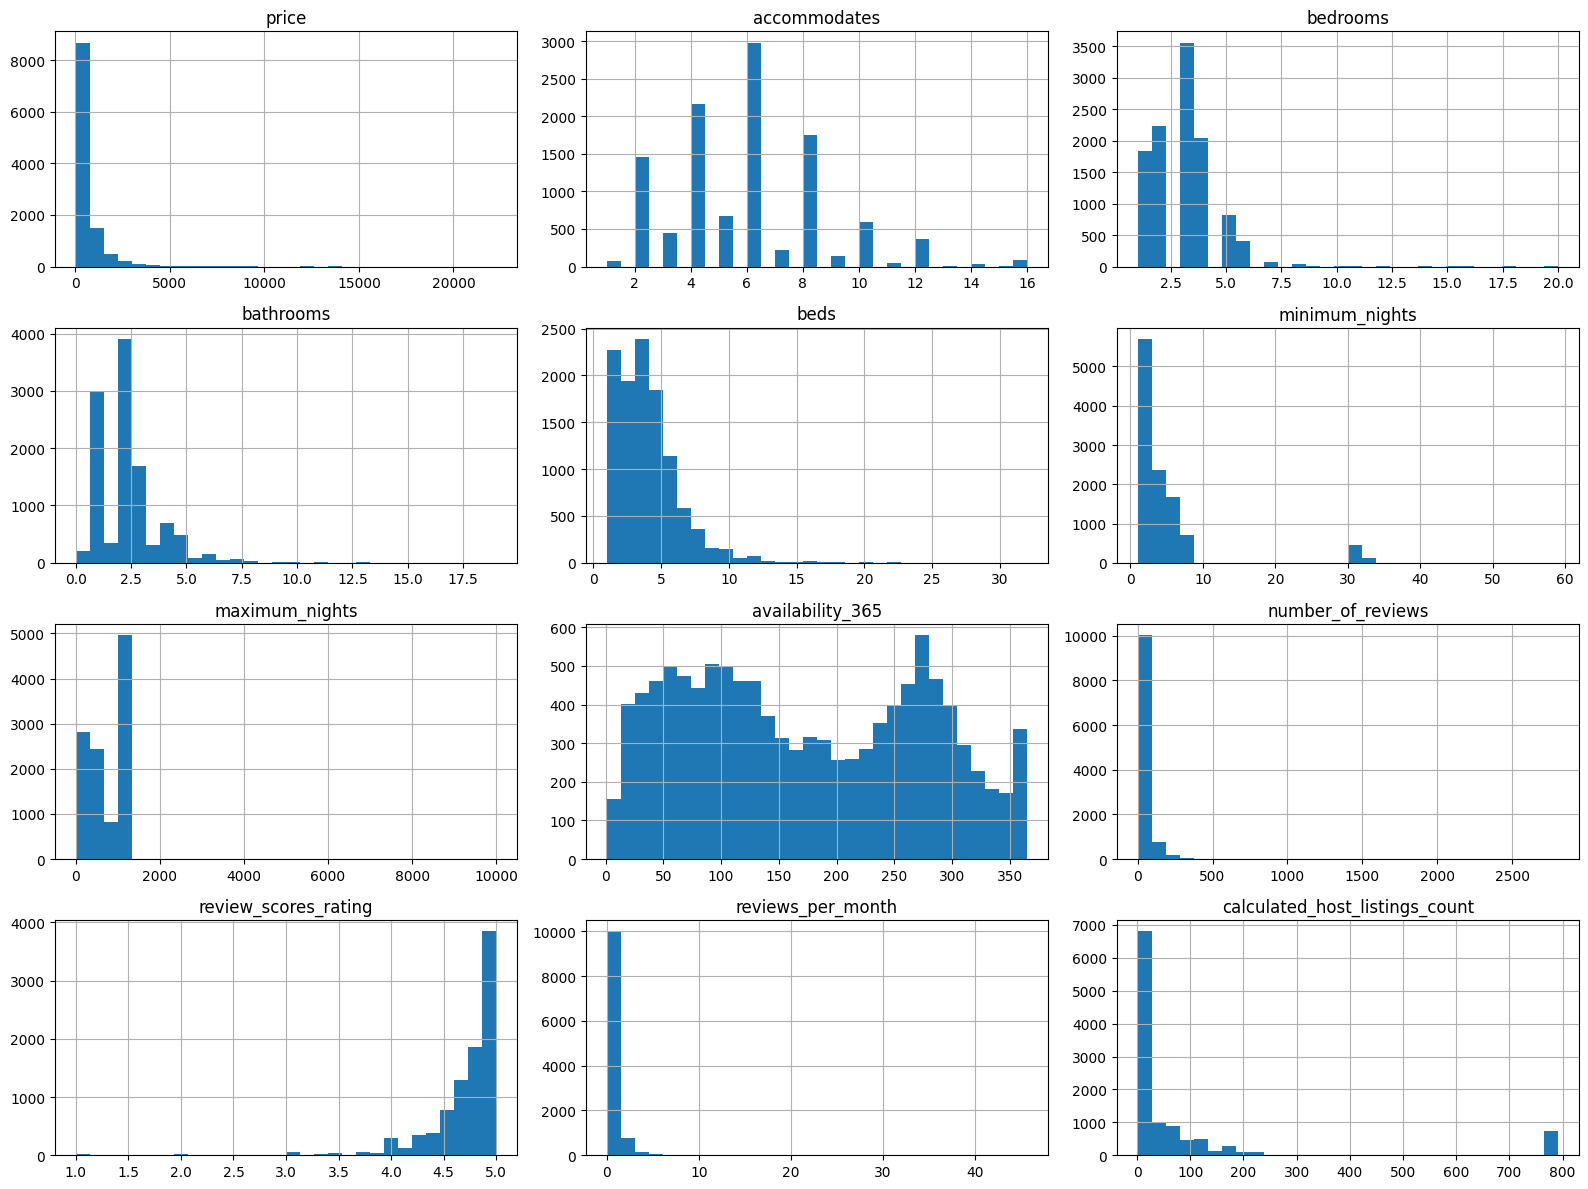

In [38]:
df[num_vars].hist(bins=30, figsize=(16, 12))
plt.tight_layout()

## 8. Outliers

Detección y tratamiento de valores extremos que puedan distorsionar el análisis.

### 8.1 Método: rango intercuartílico (IQR)

In [39]:
outlier_summary = []
for c in num_vars:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[c] < low) | (df[c] > high)).sum()
    outlier_summary.append({
        "variable": c, "low": low, "high": high,
        "n_outliers": n_outliers, "pct_outliers": round(n_outliers / len(df) * 100, 2),
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values("pct_outliers", ascending=False)
outlier_summary

,variable,low,high,n_outliers,pct_outliers
11,calculated_host_listings_count,-95.500,164.500,1086,9.83
0,price,-413.080,1333.800,1062,9.62
8,number_of_reviews,-55.000,97.000,942,8.53
10,reviews_per_month,-1.045,1.955,673,6.09
5,minimum_nights,-5.000,11.000,591,5.35
9,review_scores_rating,4.075,5.475,575,5.21
4,beds,0.000,8.000,504,4.56
3,bathrooms,-2.000,6.000,188,1.70
1,accommodates,-2.000,14.000,89,0.81
2,bedrooms,-1.000,7.000,77,0.70


`calculated_host_listings_count` encabeza la lista con fuerza: Mallorca tiene un mercado mucho más profesionalizado que las otras ciudades (gestoras con cientos de propiedades en la isla), así que un porcentaje inusualmente alto de anuncios "sobresale" en esa variable sin que sea un error.

### 8.2 ¿Hay precios disuasorios extremos, como en Málaga/Valencia?

In [40]:
df.sort_values("price", ascending=False)[["name", "neighbourhood_cleansed", "room_type", "property_type", "accommodates", "bedrooms", "number_of_reviews", "price"]].head(10)

,name,neighbourhood_cleansed,room_type,property_type,accommodates,bedrooms,number_of_reviews,price
4675,Villa Carlini,Esporles,Entire home/apt,Entire villa,10,5.0,0,22260.00
6752,Villa Port Verd,Son Servera,Entire home/apt,Entire villa,10,4.0,0,13942.00
7276,Son Vida,Palma de Mallorca,Entire home/apt,Entire home,6,3.0,0,13571.43
6474,Can Mir Sa Posada Des Pagès,Pollença,Entire home/apt,Entire villa,10,5.0,1,13482.00
3477,Son Simó Vell,Alcúdia,Entire home/apt,Entire villa,16,8.0,3,12208.00
5593,Casa Leo,Muro,Entire home/apt,Entire villa,10,5.0,3,12045.00
4883,The Yellow Castle,Andratx,Entire home/apt,Entire villa,12,6.0,0,9942.00
1377,Villa Cala Figuera,Santanyí,Entire home/apt,Entire villa,12,7.0,0,9509.60
10194,Villa Domus Alba A - B,Felanitx,Entire home/apt,Entire home,8,7.0,10,9449.00
5683,Son Rossinyol Nou,Campos,Entire home/apt,Entire rental unit,16,8.0,0,9221.00


A diferencia de Málaga (2 habitaciones con precios disuasorios de miles de euros/noche que no eran mercado real) y de Valencia (un error de captura), aquí los precios más altos son **villas de lujo reales**: `accommodates` y `bedrooms` altos (8-16 plazas, 3-8 dormitorios), nombres propios de villa (`"Villa Carlini"`, `"Son Vida"`...) y sin ningún patrón repetido de cifra redonda que delate un precio disuasorio. No se detecta ningún artefacto que limpiar.

### 8.3 ¿Y en el extremo bajo?

In [41]:
df.sort_values("price")[["name", "neighbourhood_cleansed", "room_type", "property_type", "accommodates", "bedrooms", "price"]].head(10)

,name,neighbourhood_cleansed,room_type,property_type,accommodates,bedrooms,price
9450,Gran habitación alquiler temporada no turístico.,Palma de Mallorca,Private room,Private room in home,1,1.0,22.68
14060,"Habitación 3 con baño compartido, en piso Aven...",Palma de Mallorca,Private room,Private room in rental unit,1,4.0,27.30
3897,"Habitación 2 con baño compartido, en piso Aven...",Palma de Mallorca,Private room,Private room in rental unit,1,4.0,27.30
12744,Habitación privada y baño - Alcúdia 30+ noches,Alcúdia,Private room,Private room in rental unit,2,1.0,28.23
9980,"Room Love. Palma center, only girls",Palma de Mallorca,Private room,Private room in rental unit,1,1.0,28.41
9379,Habitació clara amb bany privat. Mínim 30 díes.,Palma de Mallorca,Private room,Private room in casa particular,1,1.0,29.13
10104,"Sweet Dreams. Palma center, only girls.",Palma de Mallorca,Private room,Private room in rental unit,1,1.0,29.76
198,Camper Van Mallorca,Palma de Mallorca,Entire home/apt,Camper/RV,2,1.0,30.24
9801,Habitación con baño privado en piso de Avenidas,Palma de Mallorca,Private room,Private room in rental unit,1,4.0,30.63
4400,Ap01 Monatliche Wintervermietung/Oktober bis ...,Sencelles,Private room,Private room in rental unit,2,1.0,32.83


Tampoco hay artefactos en el extremo bajo: son habitaciones privadas reales, coherentes con su tipo y ubicación (varias en Palma, precisamente donde el mercado es más urbano/residencial que turístico-vacacional).

### 8.4 ¿Hay también un error de captura como en Valencia?

In [42]:
cols = ["name", "room_type", "accommodates", "bedrooms", "beds", "bathrooms", "price"]
error_mask = (df["bedrooms"] >= 6) & (df["beds"] >= 6) & (df["bathrooms"] >= 6)
df.loc[error_mask, cols]

,name,room_type,accommodates,bedrooms,beds,bathrooms,price
42,"Villa Blanca, gran villa ideal para familias",Entire home/apt,12,7.0,12.0,6.0,1028.00
126,"Son Serra Paradise, Beach House 5StarsHome Mal...",Entire home/apt,12,6.0,9.0,6.5,1517.00
428,Ayurvila Yoga Retreat in Mallorca,Private room,16,11.0,22.0,14.0,1825.88
569,Awesome villa in Pollensa,Entire home/apt,12,6.0,9.0,6.0,1729.29
601,Residential rental in Banyalbufar,Entire home/apt,8,8.0,8.0,7.0,454.30
...,...,...,...,...,...,...,...
14437,Beach Houses Playa de Muro twins Segalls y Fotges,Entire home/apt,12,6.0,10.0,6.0,1029.33
14447,"""NEW"" Sa Marina - Cala Ferrera, Mallorca",Entire home/apt,12,6.0,9.0,6.0,1089.29
14518,Hilltop Villa with Panoramic Views over Two Bays,Entire home/apt,12,8.0,10.0,6.0,878.08
14542,"La Tierra, Villa-Finca 5StarsHome Mallorca",Entire home/apt,12,6.0,10.0,6.5,1449.71


Ningún registro cumple ese patrón. No hay evidencia de errores de captura similares a Valencia.

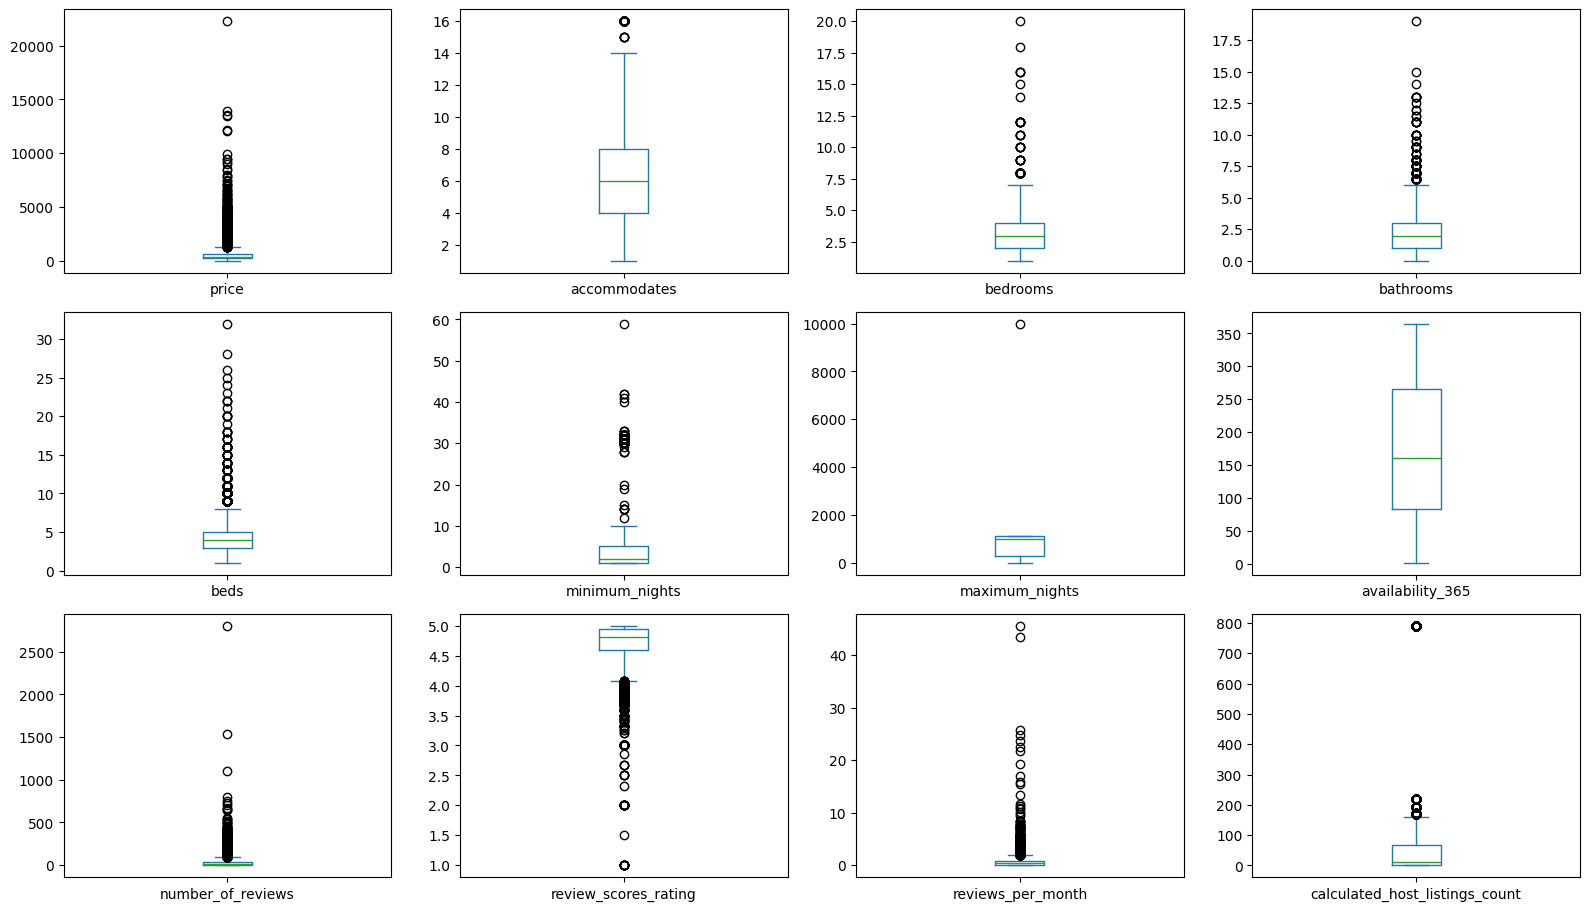

In [43]:
df[num_vars].plot(kind="box", subplots=True, layout=(4, 4), figsize=(16, 12))
plt.tight_layout()

### 8.5 Conclusión y tratamiento

Ningún outlier de `price` corresponde a un artefacto de scraping o error de captura: son villas de lujo reales en el extremo alto y habitaciones privadas económicas reales en el extremo bajo. **No se elimina ninguna fila por outliers**, igual que en Sevilla.

## 9. Agrupaciones

#### `neighbourhood_cleansed` / `room_type` (repaso rápido)

In [44]:
df.groupby("neighbourhood_cleansed")["price"].agg(["count", "mean", "median"]).sort_values("median", ascending=False)

,count,mean,median
neighbourhood_cleansed,,,
Marratxí,69,960.755942,745.200
Deyá,67,809.390597,640.000
Esporles,46,1173.005870,614.400
Santa Eugènia,10,952.686000,612.330
Andratx,165,1117.619697,570.600
Algaida,66,1007.552273,555.905
Consell,14,805.336429,533.800
Puigpunyent,28,534.806071,507.810
Ariany,54,788.165556,483.285


**El hallazgo más llamativo del EDA**: Palma de Mallorca, la capital y el municipio con más peso demográfico de la isla, aparece entre los municipios **más baratos** (mediana ~262€, casi el último de 53). Los municipios más caros son pueblos pequeños del interior o de la costa exclusiva (Marratxí, Deyá, Esporles, Andratx) con muy pocos anuncios pero dominados por villas grandes. Es la imagen invertida de Barcelona/Madrid/Valencia/Sevilla, donde el centro urbano es sistemáticamente el más caro: en una isla turística, el precio no lo marca la centralidad urbana sino el tipo de alojamiento (villa vs. piso) y la exclusividad de la zona costera/rural.

### 9.1 Tamaño: `accommodates`, `bedrooms`, `bathrooms`, `beds`

In [45]:
df.groupby("bedrooms")["price"].agg(["count", "median"])

,count,median
bedrooms,,
1.0,1833,190.500
2.0,2240,288.000
3.0,3561,408.140
4.0,2039,593.600
5.0,822,825.620
6.0,405,999.800
7.0,67,1382.670
8.0,47,1712.000
9.0,6,917.875


Relación creciente y muy limpia hasta 8 dormitorios, con saltos grandes propios de un mercado de villas: 1 → 190€, 2 → 288€, 3 → 408€, 4 → 594€, 5 → 826€, 6 → 1.000€. Los saltos son proporcionalmente mayores que en las ciudades (donde raramente se supera 1 dormitorio = 300-400€), coherente con que aquí "más dormitorios" casi siempre significa "villa completa", no "piso grande".

(0.0, 1500.0)

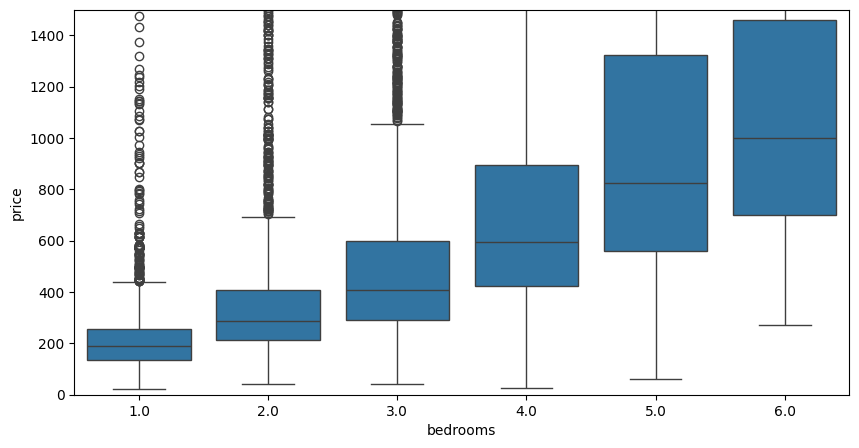

In [46]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df["bedrooms"] <= 6], x="bedrooms", y="price")
plt.ylim(0, 1500)

### 9.2 Calidad: `review_scores_rating`

In [47]:
df["price"].corr(df["review_scores_rating"]), df["price"].corr(df["review_scores_rating"], method="spearman")

(np.float64(-0.028755739120546096), np.float64(0.041232388906962285))

### 9.3 `has_license`

In [48]:
df.groupby("has_license")["price"].agg(["count", "mean", "median"])

,count,mean,median
has_license,,,
False,24,669.915000,391.085
True,11020,625.258057,398.000


Con el 99,8% de los anuncios licenciados, la comparación apenas tiene poder estadístico (solo 24 anuncios sin licencia) y la diferencia de mediana es mínima (391€ sin licencia vs. 398€ con ella): a diferencia de las otras ciudades, `has_license` es casi una constante en Mallorca y no aporta señal útil para el modelo.

In [49]:
df.groupby(["room_type", "has_license"])["price"].median()

room_type        has_license
Entire home/apt  False          713.0
                 True           416.0
Hotel room       True           252.0
Private room     False          150.0
                 True           176.0
Name: price, dtype: float64

### 9.4 `host_is_superhost`

In [50]:
df.groupby("host_is_superhost")["price"].agg(["count", "mean", "median"])

,count,mean,median
host_is_superhost,,,
False,7976,692.203251,423.9
True,3068,451.567347,342.5


Patrón inverso al esperado: los superhosts tienen mediana de precio **más baja**, no más alta. Es coherente con lo visto en property_type: los superhosts predominan entre gestores profesionales de apartamentos/pisos urbanos (con más reseñas acumuladas y mejor gestión de calendario), mientras que las villas de lujo más caras suelen tener menos reseñas y rotan menos huéspedes, así que sus propietarios rara vez alcanzan el volumen de reseñas necesario para el estatus de superhost.

### 9.5 `property_type` (más granular que `room_type`)

In [51]:
top_property_types = df["property_type"].value_counts().head(10).index
df[df["property_type"].isin(top_property_types)].groupby("property_type")["price"].median().sort_values(ascending=False)

property_type
Entire villa                   651.395
Entire home                    447.750
Entire chalet                  436.750
Entire cottage                 387.235
Entire townhouse               337.475
Entire serviced apartment      260.800
Entire rental unit             245.395
Entire condo                   242.875
Room in hotel                  194.335
Private room in rental unit    120.000
Name: price, dtype: float64

`Entire villa` domina con fuerza (mediana muy por encima del resto), confirmando que el tipo de propiedad es la variable más determinante del precio en Mallorca, por delante incluso de la localización.

## 10. Correlación y visualización

### 10.1 Correlación con `price`

In [52]:
corr_vars = num_vars + ["has_license", "host_is_superhost"]
df[corr_vars].corr(numeric_only=True)["price"].sort_values(ascending=False)

price                             1.000000
bathrooms                         0.448938
accommodates                      0.426351
bedrooms                          0.424296
calculated_host_listings_count    0.373181
beds                              0.354742
availability_365                  0.109683
has_license                      -0.002594
review_scores_rating             -0.028756
maximum_nights                   -0.131574
host_is_superhost                -0.134429
reviews_per_month                -0.135516
number_of_reviews                -0.143143
minimum_nights                   -0.150168
Name: price, dtype: float64

Con Pearson, `bathrooms` encabeza por poco (0,45), seguido de `accommodates`/`bedrooms`/`beds` (0,35-0,43): magnitudes más moderadas que en las ciudades: el precio en Mallorca depende más del **tipo de propiedad** (villa vs. piso, visto en la sección 9) que del tamaño en sí, y `property_type`/`room_type` no entran en esta matriz numérica. Con Spearman el orden cambia y `accommodates` pasa a encabezar (0,65).

In [53]:
df[corr_vars].corr(method="spearman", numeric_only=True)["price"].sort_values(ascending=False)

price                             1.000000
accommodates                      0.651251
bedrooms                          0.637948
bathrooms                         0.620731
beds                              0.547475
calculated_host_listings_count    0.296963
review_scores_rating              0.041232
availability_365                  0.025228
has_license                       0.001106
maximum_nights                   -0.054511
host_is_superhost                -0.137518
minimum_nights                   -0.210913
number_of_reviews                -0.230273
reviews_per_month                -0.265032
Name: price, dtype: float64

### 10.2 Heatmap

<Axes: >

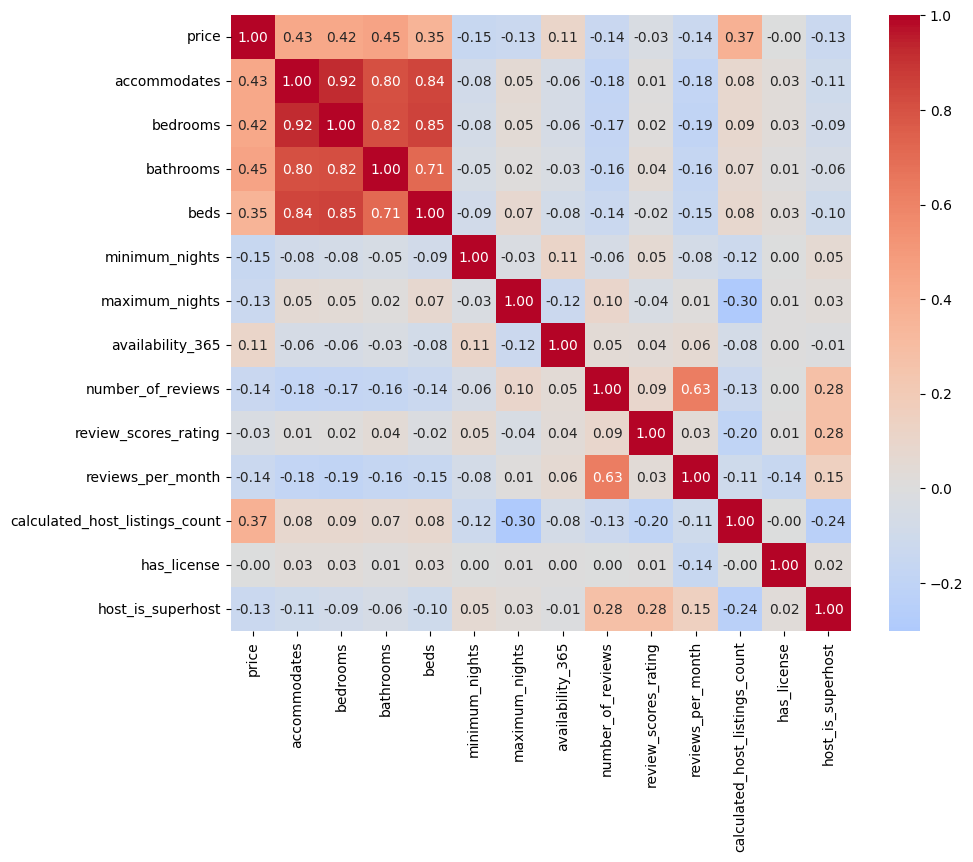

In [54]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_vars].corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)

`accommodates`/`bedrooms`/`beds`/`bathrooms` están muy correlacionadas entre sí (multicolinealidad de tamaño): se retoma en `02_feature_engineering` con VIF.

### 10.3 Pairplot

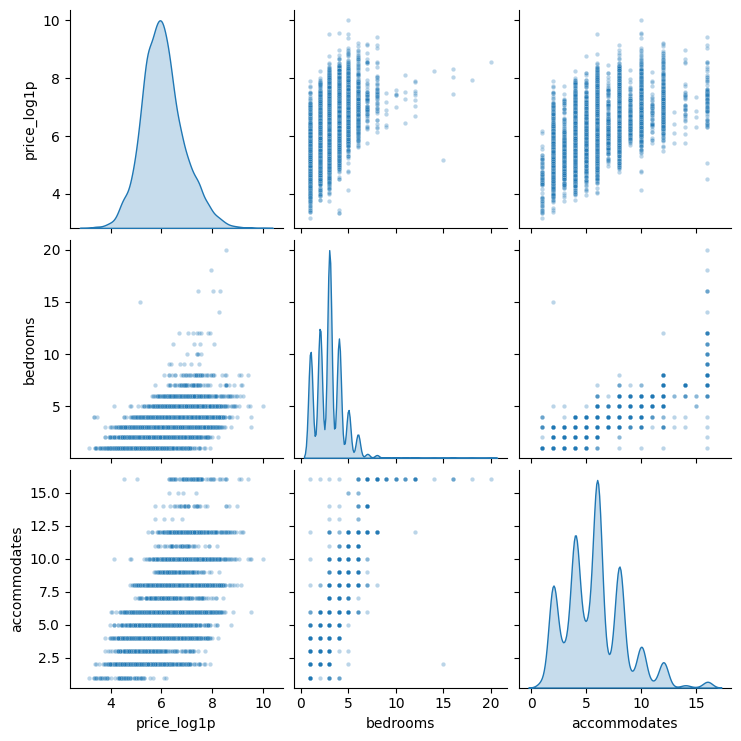

In [55]:
pairplot_data = df[["price", "bedrooms", "accommodates"]].copy()
pairplot_data["price_log1p"] = np.log1p(pairplot_data["price"])
sns.pairplot(pairplot_data[["price_log1p", "bedrooms", "accommodates"]], diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10})

Se ve la relación creciente entre `price_log1p` y ambas variables, sin colas extremas que distorsionen la nube de puntos.

## 11. Análisis geográfico

Visualización espacial de los anuncios (latitud/longitud) para entender la distribución territorial del mercado.

### 11.1 Rango de coordenadas

In [56]:
df[["latitude", "longitude"]].describe().loc[["min", "max"]]

,latitude,longitude
min,39.30207,2.346178
max,39.92973,3.474510


Rango de una isla entera, no de una sola ciudad: ~55km de latitud y ~75km de longitud, frente a los pocos kilómetros que cubren Barcelona/Madrid/Valencia/Sevilla/Málaga.

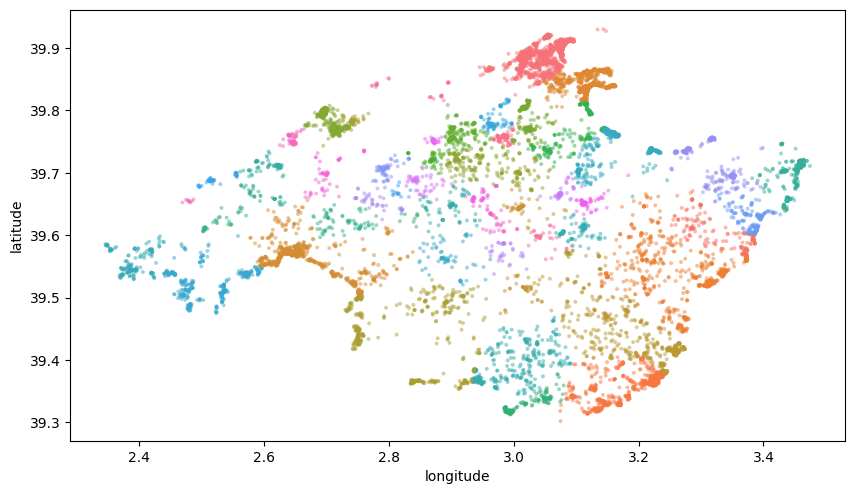

In [57]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df, x="longitude", y="latitude", hue="neighbourhood_cleansed",
    s=8, alpha=0.5, linewidth=0, legend=False,
)
plt.gca().set_aspect("equal")

### 11.2 Distribución espacial por zona

Los 53 municipios forman regiones geográficas compactas y contiguas, confirmando que `neighbourhood_cleansed` sigue de cerca los límites administrativos reales.

Text(0, 0.5, 'latitude')

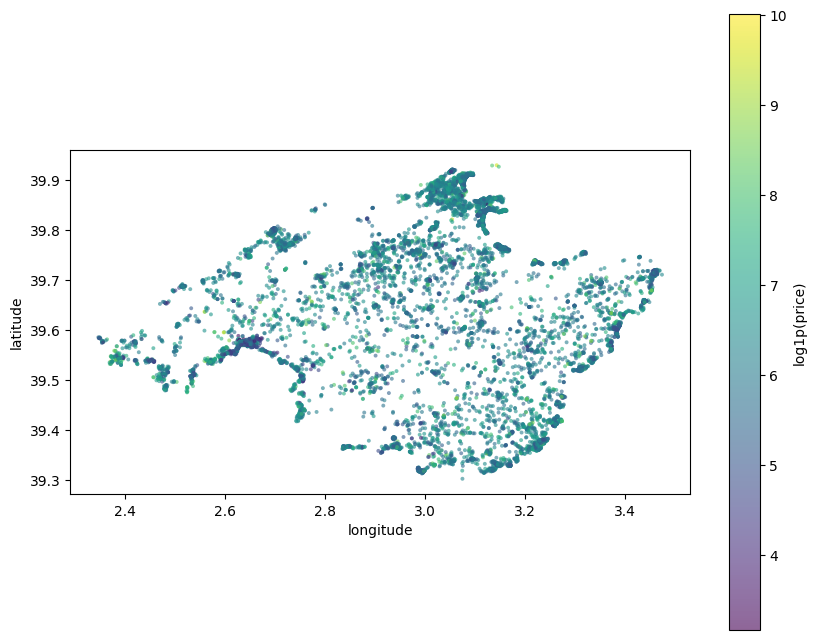

In [58]:
plt.figure(figsize=(10, 8))
sc = plt.scatter(
    df["longitude"], df["latitude"],
    c=np.log1p(df["price"]), cmap="viridis",
    s=8, alpha=0.6, linewidth=0,
)
plt.gca().set_aspect("equal")
plt.colorbar(sc, label="log1p(price)")
plt.xlabel("longitude")
plt.ylabel("latitude")

### 11.3 Precio en el mapa

Sin ningún patrón centro-periferia: los tonos más altos (precios más altos) aparecen dispersos por toda la costa y algunos puntos del interior, no concentrados alrededor de Palma. Confirma visualmente el hallazgo de la sección 9: la capital no es el foco de precios altos en esta isla.

### 11.4 ¿Dónde están los anuncios grandes?

In [59]:
df.loc[df["bedrooms"] >= 6, "neighbourhood_cleansed"].value_counts().head(10)

neighbourhood_cleansed
Palma de Mallorca    48
Felanitx             47
Manacor              46
Pollença             41
Santanyí             36
Campos               35
Alcúdia              26
Llucmajor            22
Petra                21
Calvià               17
Name: count, dtype: int64

### 11.5 Densidad de anuncios cercanos

In [60]:
from sklearn.neighbors import BallTree

coords_rad = np.radians(df[["latitude", "longitude"]].to_numpy())
tree = BallTree(coords_rad, metric="haversine")
EARTH_R_KM = 6371
radius_m = 150
counts = tree.query_radius(coords_rad, r=(radius_m / 1000) / EARTH_R_KM, count_only=True)
n_nearby_150m = counts - 1

pd.Series(n_nearby_150m, name="n_nearby_150m").describe()

count    11044.000000
mean         6.117168
std          8.052488
min          0.000000
25%          1.000000
50%          3.000000
75%          8.000000
max         53.000000
Name: n_nearby_150m, dtype: float64

In [61]:
pd.Series(n_nearby_150m, index=df.index, name="n_nearby_150m").corr(df["price"])

np.float64(-0.12870681243167093)

Correlación negativa débil: en una isla, la densidad de anuncios vecinos marca más "zona turística masificada de apartamentos baratos" que "zona prime", al revés de lo que suele pasar en el centro histórico de una ciudad.

## 12. Amenities

En la sección 6.1 `amenities` se clasificó como "cuasi-identificador" (muy alta cardinalidad de combinaciones). Se examina en detalle.

### 12.1 Formato y cardinalidad

In [62]:
import ast
from collections import Counter

amenities_parsed = df["amenities"].apply(ast.literal_eval)
n_amenities = amenities_parsed.apply(len)

print("nulos:", df["amenities"].isna().sum())
n_amenities.describe()

nulos: 0


count    11044.000000
mean        38.772999
std         15.726829
min          0.000000
25%         29.000000
50%         37.000000
75%         49.000000
max         98.000000
Name: amenities, dtype: float64

In [63]:
amenity_counter = Counter()
for lst in amenities_parsed:
    amenity_counter.update(lst)

n_once = sum(1 for c in amenity_counter.values() if c == 1)
print("valores distintos de amenity:", len(amenity_counter))
print(f"aparecen una sola vez: {n_once} de {len(amenity_counter)} ({n_once / len(amenity_counter):.0%})")

valores distintos de amenity: 2389
aparecen una sola vez: 1351 de 2389 (57%)


### 12.2 Top amenities

In [64]:
pd.Series(dict(amenity_counter.most_common(12)), name="n_anuncios")

Wifi                     10485
Kitchen                  10324
Hair dryer                9585
Dishes and silverware     9203
Bed linens                9102
Hot water                 8924
Iron                      8898
Microwave                 8769
Refrigerator              8400
Essentials                8192
Hangers                   7972
Dishwasher                7606
Name: n_anuncios, dtype: int64

### 12.3 Candidatas para feature engineering

In [65]:
def has_any(lst, keywords, exclude=None):
    for item in lst:
        low = item.lower()
        if exclude and any(ex in low for ex in exclude):
            continue
        if any(kw in low for kw in keywords):
            return True
    return False

candidates = pd.DataFrame({
    "n_amenities": n_amenities,
    "has_pool": amenities_parsed.apply(lambda l: has_any(l, ["pool"], exclude=["pool table"])),
    "has_sea_view": amenities_parsed.apply(lambda l: has_any(l, ["sea view", "ocean view"])),
    "has_ac": amenities_parsed.apply(lambda l: has_any(l, ["air condition"])),
})
candidates["price"] = df["price"]

for col in ["n_amenities", "has_pool", "has_sea_view", "has_ac"]:
    prevalencia = candidates[col].mean() if col == "n_amenities" else candidates[col].mean() * 100
    corr = candidates[col].astype(float).corr(candidates["price"])
    label = f"media={prevalencia:.1f}" if col == "n_amenities" else f"prevalencia={prevalencia:.1f}%"
    print(f"{col:16s} {label:18s} corr con price: {corr:.3f}")

n_amenities      media=38.8         corr con price: 0.034
has_pool         prevalencia=69.8%  corr con price: 0.197
has_sea_view     prevalencia=12.1%  corr con price: 0.126
has_ac           prevalencia=72.5%  corr con price: 0.081


`has_pool` está presente en **7 de cada 10 anuncios**, muchísimo más que en cualquier otra ciudad (donde rondaba el 5-25%), coherente con el peso de las villas. Precisamente por estar tan generalizada, su poder discriminante (correlación con `price`) es más moderado (0,20): cuando casi todo el mundo tiene piscina, tenerla deja de diferenciar tanto. `has_sea_view` es mucho más selectiva (solo ~1 de cada 8 anuncios) pero conserva una correlación relevante (0,13) pese a ser mucho menos frecuente: variable propia de una isla que no existe como concepto en ninguna de las otras cinco ciudades del proyecto.

## 13. Conclusiones

Resumen de los principales hallazgos del EDA.

### Limpieza aplicada

De las 14.817 filas y 90 columnas originales, tras la limpieza:
- 13 columnas 100% vacías eliminadas (las 12 comunes + `neighbourhood_group_cleansed`).
- `bathrooms` recuperada casi por completo desde `bathrooms_text`.
- Filas sin `price` descartadas (25,4% del total, la proporción más alta de las seis ciudades).
- `bedrooms`/`beds` imputados con la mediana por `room_type`.
- `has_availability` eliminada por ser constante tras la limpieza.
- Ningún outlier de `price` eliminado: no hay artefactos de scraping ni errores de captura, a diferencia de Valencia/Málaga.

### Variables nuevas

- `has_license`: flag booleano derivado de `license` (99,6% `True`, casi constante).

### El hallazgo principal: la isla invierte la lógica centro-periferia

- Palma de Mallorca, la capital, está entre los municipios **más baratos** de los 53 (mediana 262€, tercera posición empezando por abajo), mientras que pueblos pequeños del interior/costa exclusiva (Marratxí, Deyá, Esporles, Andratx) encabezan el ranking de precios.
- El precio en Mallorca depende sobre todo del **tipo de propiedad** (`Entire villa`/`Entire home` suman el 59,3% de los anuncios, frente al peso residual de pisos urbanos) y del tamaño, no de la centralidad geográfica.
- `has_pool` (70% de prevalencia) y `has_sea_view` son variables inéditas en el proyecto hasta ahora, propias de un mercado vacacional insular.

### Un mercado mucho más profesionalizado

- `calculated_host_listings_count` tiene una mediana de 10 y una media de casi 85 (frente a valores de un solo dígito en las ciudades): gestoras con cientos de propiedades dominan una parte relevante del mercado.

### De cara al modelado (decisiones diferidas, no aplicadas aquí)

- `accommodates`/`bedrooms`/`beds`/`bathrooms` correlacionadas entre sí: vigilar VIF en feature engineering.
- `has_license` casi constante (99,6%): probablemente poca utilidad predictiva real.
- Sin distancia a un "centro" único claro (a diferencia de las ciudades): se decidirá en feature engineering qué punto de referencia usar, si alguno, para una variable de distancia.

## 14. Exportar dataset limpio

Guardar el dataset resultante tras la limpieza en `data/processed/mallorca/`.

In [66]:
df.shape

(11044, 77)

In [67]:
df.to_csv(f"{PROJECT_DIR}/data/processed/mallorca/listings_full_clean.csv", index=False)